# 01 — Exploratory Data Analysis

**Research question:** Does ward-level colonization pressure (environmental exposure)
or antibiotic exposure history (patient exposure) better predict hospital-onset MRSA
acquisition?

This notebook loads `HO_infxn_analysis.csv`, filters to the MRSA subsets of both matched
cohorts (`environmental` and `patient`), fixes the `age` column's `'>90'` privacy-censoring
text value, and profiles both subsets before any modeling.

See [DATA_ACCESS.md](../DATA_ACCESS.md) for what the two `analysis` arms mean and how they
differ in matching strategy.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.data_loading import load_raw, clean_age, save_processed

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## Load raw data and get oriented

In [2]:
raw = load_raw()
print(raw.shape)
raw.head()

(120279, 78)


,analysis,run,group,group_binary,group_index,deidentified_patient_id,deidentified_month,deidentified_year,dept_code,duration,time_to_infxn,matching_duration,age,sex,any_surgery,any_abx_0_60,penicillin_0_60,extended_spectrum_penicillin_0_60,anti_staph_beta_lactam_0_60,cephalosporin_0_60,extended_spectrum_cephalosporin_0_60,carbapenem_0_60,fluoroquinolone_0_60,sulfonamide_0_60,glycopeptide_0_60,anti_Cdiff_0_60,anti_anaerobe_0_60,lincosamide_0_60,macrolide_0_60,tetracycline_0_60,DS_Entero_cp,ESBL_cp,CDiff_cp,VSE_cp,VRE_cp,MSSA_cp,MRSA_cp,DS_PsA_cp,DR_PsA_cp,elix_index_mortality,elix_AIDS,elix_LUNG_CHRONIC,elix_DEMENTIA,elix_DEPRESS,elix_DIAB_UNCX,elix_DIAB_CX,elix_HTN_UNCX,elix_THYROID_HYPO,elix_THYROID_OTH,elix_CANCER_LYMPH,elix_CANCER_LEUK,elix_CANCER_METS,elix_OBESE,elix_PERIVASC,elix_CANCER_SOLID,elix_CANCER_NSITU,elix_ANEMDEF,elix_BLDLOSS,elix_COAG,elix_LIVER_SEV,elix_NEURO_MOVT,elix_NEURO_SEIZ,elix_PULMCIRC,elix_RENLFL_MOD,elix_ULCER_PEPTIC,elix_WGHTLOSS,elix_DRUG_ABUSE,elix_HTN_CX,elix_ALCOHOL,elix_AUTOIMMUNE,elix_PSYCHOSES,elix_HF,elix_RENLFL_SEV,elix_PARALYSIS,elix_LIVER_MLD,elix_VALVE,elix_NEURO_OTH,elix_CBVD
0,environmental,C_diff,control,0,1,33784,2066-02-01,2066,86,10.1,NaN,10.1,74.5,Female,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,17.144140,6.521118,2.233758,6.037091,7.208069,5.092690,0.743018,4.501895,1.458188,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,environmental,C_diff,case,1,1,32224,2078-01-01,2078,214,16.0,10.2,10.2,71.1,Female,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.160149,3.503223,0.000000,0.000000,0.000000,0.784626,0.901181,1.374666,0.000000,19,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,environmental,C_diff,control,0,2,32346,2091-10-01,2091,68,2.0,NaN,2.0,60.4,Female,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.858923,1.317211,0.872255,0.000000,0.000000,1.701632,0.621229,0.000000,1.712033,1,0,0,0,1,0,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1
3,environmental,C_diff,case,1,2,27955,2017-04-01,2017,25,2.0,18.2,2.0,60.4,Female,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.257791,1.563165,0.000000,0.704492,0.000000,1.555627,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,environmental,C_diff,control,0,3,19691,2012-04-01,2012,189,3.1,NaN,3.1,43.4,Female,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9.337238,2.615545,0.000000,0.902597,0.000000,5.470810,1.257394,2.421407,0.000000,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
raw.dtypes.value_counts()

int64      60
float64    12
object      6
Name: count, dtype: int64

## Confirm `analysis` and `run` values

Before filtering, confirm the exact category labels — the data dictionary describes them
but doesn't give literal strings (e.g. `run` may read `"MRSA"` or a longer phenotype
label).

In [4]:
print(raw["analysis"].value_counts())
print()
print(raw["run"].value_counts())

analysis
patient          67343
environmental    52936
Name: count, dtype: int64

run
DS_E_coli            23729
MSSA                 17218
VSE_faecalis         12987
DS_K_pneumoniae      11305
DS_P_aeruginosa       8913
MRSA                  7256
ESBL_E_coli           6840
C_diff                5125
DS_P_mirabilis        4874
DS_E_cloacae          3825
DS_K_oxytoca          3145
DS_S_marcescens       2969
DR_P_aeruginosa       2620
VSE_faecium           1999
VRE_faecium           1961
ESBL_E_cloacae        1906
ESBL_P_mirabilis      1853
ESBL_K_pneumoniae     1754
Name: count, dtype: int64


## Filter to MRSA cases/controls, for each analysis arm separately

In [5]:
env = raw[(raw["analysis"].str.lower() == "environmental") &
          (raw["run"].astype(str).str.contains("MRSA", case=False, na=False))].copy()
pat = raw[(raw["analysis"].str.lower() == "patient") &
          (raw["run"].astype(str).str.contains("MRSA", case=False, na=False))].copy()

print("environmental MRSA subset:", env.shape)
print("patient MRSA subset:", pat.shape)

# Sanity check against the PhysioNet data dictionary's published sample sizes:
# environmental MRSA: 1,101 cases / 2,397 controls
# patient MRSA:       1,102 cases / 2,656 controls
print(env["group_binary"].value_counts())
print(pat["group_binary"].value_counts())

environmental MRSA subset: (3498, 78)
patient MRSA subset: (3758, 78)
group_binary
0    2397
1    1101
Name: count, dtype: int64
group_binary
0    2656
1    1102
Name: count, dtype: int64


## Fix `age`

Ages >=90 are recorded as the literal string `'>90'` for privacy, so the column can't be
treated as numeric as-is. `clean_age` recodes it to a numeric sentinel and adds an
`age_over_90` flag so the censoring stays visible rather than silently biasing the mean
downward.

In [6]:
raw["age"].apply(type).value_counts()

age
<class 'str'>    120279
Name: count, dtype: int64

In [7]:
env = clean_age(env)
pat = clean_age(pat)

print("environmental age_over_90 rate:", env["age_over_90"].mean().round(4))
print("patient age_over_90 rate:", pat["age_over_90"].mean().round(4))
env[["age", "age_over_90"]].describe(include="all")

environmental age_over_90 rate: 0.0369
patient age_over_90 rate: 0.0729


,age,age_over_90
count,3498.000000,3498
unique,NaN,2
top,NaN,False
freq,NaN,3369
mean,58.005918,NaN
std,24.172610,NaN
min,0.000000,NaN
25%,43.400000,NaN
50%,63.700000,NaN
75%,75.800000,NaN


## Missingness

In [8]:
env.isna().mean().sort_values(ascending=False).head(20)

time_to_infxn                        0.685249
run                                  0.000000
analysis                             0.000000
group_binary                         0.000000
group_index                          0.000000
deidentified_patient_id              0.000000
group                                0.000000
deidentified_month                   0.000000
deidentified_year                    0.000000
dept_code                            0.000000
duration                             0.000000
matching_duration                    0.000000
age                                  0.000000
sex                                  0.000000
any_surgery                          0.000000
any_abx_0_60                         0.000000
penicillin_0_60                      0.000000
extended_spectrum_penicillin_0_60    0.000000
anti_staph_beta_lactam_0_60          0.000000
cephalosporin_0_60                   0.000000
dtype: float64

In [9]:
pat.isna().mean().sort_values(ascending=False).head(20)

time_to_infxn                        0.706759
run                                  0.000000
analysis                             0.000000
group_binary                         0.000000
group_index                          0.000000
deidentified_patient_id              0.000000
group                                0.000000
deidentified_month                   0.000000
deidentified_year                    0.000000
dept_code                            0.000000
duration                             0.000000
matching_duration                    0.000000
age                                  0.000000
sex                                  0.000000
any_surgery                          0.000000
any_abx_0_60                         0.000000
penicillin_0_60                      0.000000
extended_spectrum_penicillin_0_60    0.000000
anti_staph_beta_lactam_0_60          0.000000
cephalosporin_0_60                   0.000000
dtype: float64

## Check matching assumptions

The environmental cohort is matched on age/sex, so case vs. control distributions of age
and sex should look near-identical there. The patient cohort is **not** matched on
age/sex — if those distributions diverge here, it confirms the model in
`04b_logreg_patient.ipynb` needs to control for age/sex explicitly rather than relying on
the match.

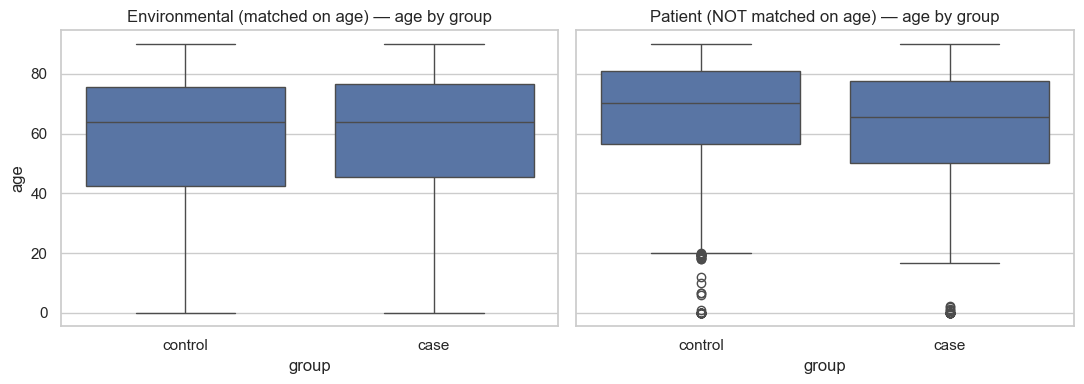

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sns.boxplot(data=env, x="group", y="age", ax=axes[0])
axes[0].set_title("Environmental (matched on age) — age by group")
sns.boxplot(data=pat, x="group", y="age", ax=axes[1])
axes[1].set_title("Patient (NOT matched on age) — age by group")
plt.tight_layout()

In [11]:
print("Environmental — sex by group (row %):")
print(pd.crosstab(env["group"], env["sex"], normalize="index").round(3))
print()
print("Patient — sex by group (row %):")
print(pd.crosstab(pat["group"], pat["sex"], normalize="index").round(3))

Environmental — sex by group (row %):
sex      Female   Male
group                 
case      0.440  0.560
control   0.454  0.546

Patient — sex by group (row %):
sex      Female   Male
group                 
case      0.430  0.570
control   0.584  0.416


## Class balance and key predictor distributions

Colonization pressure columns: ['DS_Entero_cp', 'ESBL_cp', 'CDiff_cp', 'VSE_cp', 'VRE_cp', 'MSSA_cp', 'MRSA_cp', 'DS_PsA_cp', 'DR_PsA_cp']


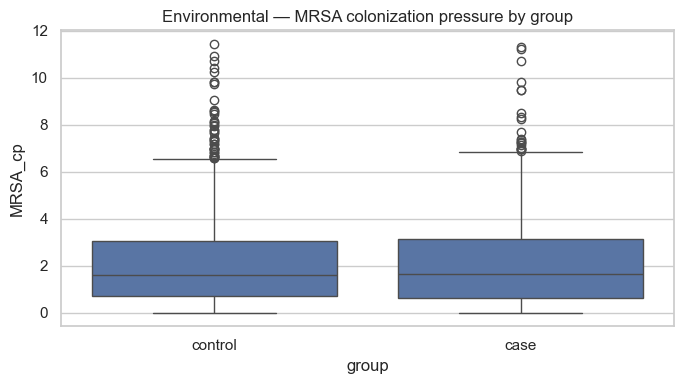

In [12]:
cp_cols = [c for c in env.columns if c.endswith("_cp")]
print("Colonization pressure columns:", cp_cols)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=env, x="group", y="MRSA_cp", ax=ax)
ax.set_title("Environmental — MRSA colonization pressure by group")
plt.tight_layout()

In [13]:
abx_cols = [c for c in pat.columns if c.endswith("_0_60") and c != "any_abx_0_60"]
print("Antibiotic class course-count columns:", abx_cols)

pat.groupby("group")[abx_cols].mean().T.sort_values("case", ascending=False)

Antibiotic class course-count columns: ['penicillin_0_60', 'extended_spectrum_penicillin_0_60', 'anti_staph_beta_lactam_0_60', 'cephalosporin_0_60', 'extended_spectrum_cephalosporin_0_60', 'carbapenem_0_60', 'fluoroquinolone_0_60', 'sulfonamide_0_60', 'glycopeptide_0_60', 'anti_Cdiff_0_60', 'anti_anaerobe_0_60', 'lincosamide_0_60', 'macrolide_0_60', 'tetracycline_0_60']


group,case,control
fluoroquinolone_0_60,0.045372,0.048946
cephalosporin_0_60,0.030853,0.048569
tetracycline_0_60,0.017241,0.028991
extended_spectrum_penicillin_0_60,0.014519,0.024473
macrolide_0_60,0.013612,0.018825
glycopeptide_0_60,0.011797,0.006401
penicillin_0_60,0.006352,0.013178
sulfonamide_0_60,0.003630,0.033886
extended_spectrum_cephalosporin_0_60,0.003630,0.007530
anti_Cdiff_0_60,0.002722,0.003765


## Save cleaned MRSA subsets for downstream notebooks

In [14]:
save_processed(env, "environmental_mrsa.csv")
save_processed(pat, "patient_mrsa.csv")

WindowsPath('C:/Users/Alexander Jimenez/OneDrive/Desktop/mrsa-infection-analysis/data/processed/patient_mrsa.csv')

## Next steps

- `02_correlation_analysis.ipynb` — correlation structure among candidate predictors
  within each arm.
- `03_hypothesis_testing.ipynb` — formal case vs. control comparisons.
- `04a_logreg_environmental.ipynb` / `04b_logreg_patient.ipynb` — logistic regression per
  analysis arm (patient model controls for age/sex explicitly, per the imbalance checked
  above).